# Clase 8.2: TensorFlow/Keras y PyTorch
## Construcción de Redes Neuronales en Python

En esta clase aprenderemos a implementar redes neuronales usando dos frameworks principales:
- **TensorFlow/Keras**: API de alto nivel, ideal para principiantes
- **PyTorch**: Más flexible, preferido en investigación

## Parte 1: Conceptos Fundamentales

### Una Red Neuronal es:

```
Entrada → Capa 1 → Capa 2 → ... → Salida
   (x)    (64 neuronas) (32 neuronas)  (1 neurona)
```

**Matemática básica:**
- Cada neurona: `z = W·x + b`
- Activación: `a = f(z)` (ReLU, Sigmoid, etc.)
- Forward pass: datos fluyen de entrada a salida
- Backward pass: gradientes fluyen hacia atrás para actualizar pesos

## Parte 2: TensorFlow/Keras

In [9]:
# Instalar (si no lo has hecho)
!pip install tensorflow numpy pandas matplotlib scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.21.0
GPU disponible: []


### 2.1 Crear un Modelo Simple (Sequential)

In [11]:
# Crear modelo secuencial (pila lineal de capas)
modelo_keras = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(20,)),  # Entrada: 20 features, 64 neuronas
    layers.Dropout(0.2),  # Regularización: desactiva 20% de neuronas
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')  # Salida: probabilidad (0 o 1)
])

# Compilar
modelo_keras.compile(
    optimizer='adam',  # Optimizador adaptativo
    loss='binary_crossentropy',  # Para clasificación binaria
    metrics=['accuracy']
)

# Ver arquitectura
modelo_keras.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

### 2.2 Generar Datos de Ejemplo

In [12]:
# Generar datos sintéticos
np.random.seed(42)

X_train = np.random.randn(1000, 20)  # 1000 muestras, 20 features
y_train = np.random.randint(0, 2, 1000)  # Labels: 0 o 1

X_val = np.random.randn(200, 20)
y_val = np.random.randint(0, 2, 200)

X_test = np.random.randn(200, 20)
y_test = np.random.randint(0, 2, 200)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (1000, 20)
y_train shape: (1000,)


### 2.3 Entrenar el Modelo

In [13]:
# Entrenar
historial = modelo_keras.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5240 - loss: 0.7213 - val_accuracy: 0.5250 - val_loss: 0.6817
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 728us/step - accuracy: 0.5240 - loss: 0.7084 - val_accuracy: 0.5200 - val_loss: 0.6829
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 687us/step - accuracy: 0.5050 - loss: 0.7058 - val_accuracy: 0.5250 - val_loss: 0.6844
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step - accuracy: 0.5480 - loss: 0.6920 - val_accuracy: 0.5350 - val_loss: 0.6875
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step - accuracy: 0.5640 - loss: 0.6798 - val_accuracy: 0.5450 - val_loss: 0.6888
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step - accuracy: 0.5530 - loss: 0.6842 - val_accuracy: 0.5550 - val_loss: 0.6886
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step - accuracy: 0.5710 - loss: 0.6800 - val_accuracy: 0.5450 - val_loss: 0.6897
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 622us/step - accuracy: 0.5740 - loss: 0.6713 - val_accuracy: 0.57

### 2.4 Evaluar el Modelo

In [14]:
# Evaluar en test set
loss, accuracy = modelo_keras.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.2%}")

Test Loss: 0.7470
Test Accuracy: 46.00%


### 2.5 Hacer Predicciones

In [15]:
# Predecir en nuevas muestras
muestras_nuevas = X_test[:5]
predicciones = modelo_keras.predict(muestras_nuevas)

print("Primeras 5 predicciones (probabilidades):")
for i, pred in enumerate(predicciones):
    clase = "Clase 1" if pred[0] > 0.5 else "Clase 0"
    print(f"  Muestra {i}: {pred[0]:.4f} → {clase}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Primeras 5 predicciones (probabilidades):
  Muestra 0: 0.4469 → Clase 0
  Muestra 1: 0.5096 → Clase 1
  Muestra 2: 0.3234 → Clase 0
  Muestra 3: 0.6627 → Clase 1
  Muestra 4: 0.5109 → Clase 1


### 2.6 Visualizar Entrenamiento

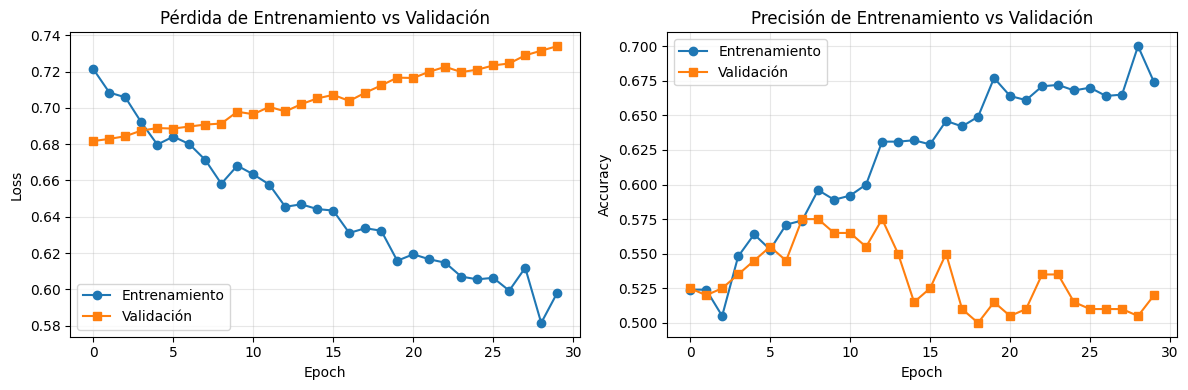

In [16]:
# Graficar curvas de entrenamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.plot(historial.history['loss'], label='Entrenamiento', marker='o')
ax1.plot(historial.history['val_loss'], label='Validación', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Pérdida de Entrenamiento vs Validación')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(historial.history['accuracy'], label='Entrenamiento', marker='o')
ax2.plot(historial.history['val_accuracy'], label='Validación', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Precisión de Entrenamiento vs Validación')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Parte 3: PyTorch

In [17]:
# Instalar (si no lo has hecho)
!pip install torch

  Using cached torch-2.11.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (29 kB)
  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (2.7 kB)
Using cached torch-2.11.0-cp312-cp312-macosx_11_0_arm64.whl (80.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 995.8 kB/s eta 0:00:00a 0:00:01
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached setuptools-81.0.0-py3-none-any.whl (1.1 MB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp312-cp312-macosx_11_0_arm64.whl (12 kB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
  Attempting unin

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

print(f"PyTorch version: {torch.__version__}")
print(f"GPU disponible: {torch.cuda.is_available()}")

PyTorch version: 2.11.0
GPU disponible: False


### 3.1 Definir Arquitectura de Red

In [19]:
# Crear clase personalizada para la red neuronal
class RedNeuronalPyTorch(nn.Module):
    def __init__(self, input_size=20, hidden1=64, hidden2=32):
        super().__init__()
        
        # Definir capas
        self.fc1 = nn.Linear(input_size, hidden1)
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)
        
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.dropout2 = nn.Dropout(0.2)
        
        self.fc3 = nn.Linear(hidden2, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        # Forward pass
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout1(x)
        
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout2(x)
        
        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

# Crear instancia
modelo_pytorch = RedNeuronalPyTorch(input_size=20)
print(modelo_pytorch)

RedNeuronalPyTorch(
  (fc1): Linear(in_features=20, out_features=64, bias=True)
  (relu): ReLU()
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


### 3.2 Preparar Datos

In [20]:
# Convertir a tensores PyTorch
X_train_torch = torch.FloatTensor(X_train)
y_train_torch = torch.FloatTensor(y_train).reshape(-1, 1)

X_val_torch = torch.FloatTensor(X_val)
y_val_torch = torch.FloatTensor(y_val).reshape(-1, 1)

X_test_torch = torch.FloatTensor(X_test)
y_test_torch = torch.FloatTensor(y_test).reshape(-1, 1)

print(f"X_train_torch shape: {X_train_torch.shape}")
print(f"y_train_torch shape: {y_train_torch.shape}")

X_train_torch shape: torch.Size([1000, 20])
y_train_torch shape: torch.Size([1000, 1])


### 3.3 Crear DataLoaders

In [21]:
# DataLoaders para batch processing
batch_size = 32

train_dataset = TensorDataset(X_train_torch, y_train_torch)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val_torch, y_val_torch)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Número de batches en entrenamiento: {len(train_loader)}")

Número de batches en entrenamiento: 32


### 3.4 Configurar Entrenamiento

In [22]:
# Loss y optimizador
criterio = nn.BCELoss()  # Binary Cross Entropy
optimizador = optim.Adam(modelo_pytorch.parameters(), lr=0.001)

print("Configuración lista:")
print(f"  Criterio: {criterio}")
print(f"  Optimizador: {optimizador}")

Configuración lista:
  Criterio: BCELoss()
  Optimizador: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


### 3.5 Entrenar el Modelo

In [23]:
# Entrenar
num_epochs = 30
historial_pytorch = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

modelo_pytorch.train()  # Modo entrenamiento

for epoch in range(num_epochs):
    # Entrenamiento
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for batch_X, batch_y in train_loader:
        # Forward pass
        y_pred = modelo_pytorch(batch_X)
        
        # Calcular loss
        loss = criterio(y_pred, batch_y)
        
        # Backward pass
        optimizador.zero_grad()  # Limpiar gradientes
        loss.backward()  # Calcular gradientes
        optimizador.step()  # Actualizar pesos
        
        # Acumular métricas
        train_loss += loss.item()
        predictions = (y_pred > 0.5).int()
        train_correct += (predictions == batch_y).sum().item()
        train_total += batch_y.size(0)
    
    # Validación
    modelo_pytorch.eval()  # Modo evaluación
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            y_pred = modelo_pytorch(batch_X)
            loss = criterio(y_pred, batch_y)
            
            val_loss += loss.item()
            predictions = (y_pred > 0.5).int()
            val_correct += (predictions == batch_y).sum().item()
            val_total += batch_y.size(0)
    
    modelo_pytorch.train()  # Volver a modo entrenamiento
    
    # Guardar métricas
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    
    historial_pytorch['loss'].append(avg_train_loss)
    historial_pytorch['val_loss'].append(avg_val_loss)
    historial_pytorch['accuracy'].append(train_acc)
    historial_pytorch['val_accuracy'].append(val_acc)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {avg_train_loss:.4f}, Accuracy: {train_acc:.2%}")
        print(f"  Val Loss: {avg_val_loss:.4f}, Accuracy: {val_acc:.2%}")

Epoch 10/30
  Train Loss: 0.6616, Accuracy: 61.50%
  Val Loss: 0.7188, Accuracy: 49.00%
Epoch 20/30
  Train Loss: 0.6227, Accuracy: 65.90%
  Val Loss: 0.7571, Accuracy: 46.00%
Epoch 30/30
  Train Loss: 0.5682, Accuracy: 72.70%
  Val Loss: 0.8020, Accuracy: 48.50%


### 3.6 Evaluar en Test Set

In [24]:
# Evaluar
modelo_pytorch.eval()
with torch.no_grad():
    y_test_pred = modelo_pytorch(X_test_torch)
    test_loss = criterio(y_test_pred, y_test_torch).item()
    
    predictions = (y_test_pred > 0.5).int()
    test_accuracy = (predictions == y_test_torch).float().mean().item()

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2%}")

Test Loss: 0.7990
Test Accuracy: 43.50%


### 3.7 Hacer Predicciones

In [25]:
# Predecir
modelo_pytorch.eval()
with torch.no_grad():
    predicciones_pytorch = modelo_pytorch(X_test_torch[:5])

print("Primeras 5 predicciones (PyTorch):")
for i, pred in enumerate(predicciones_pytorch):
    clase = "Clase 1" if pred.item() > 0.5 else "Clase 0"
    print(f"  Muestra {i}: {pred.item():.4f} → {clase}")

Primeras 5 predicciones (PyTorch):
  Muestra 0: 0.2785 → Clase 0
  Muestra 1: 0.3335 → Clase 0
  Muestra 2: 0.4702 → Clase 0
  Muestra 3: 0.4796 → Clase 0
  Muestra 4: 0.4292 → Clase 0


### 3.8 Visualizar Entrenamiento PyTorch

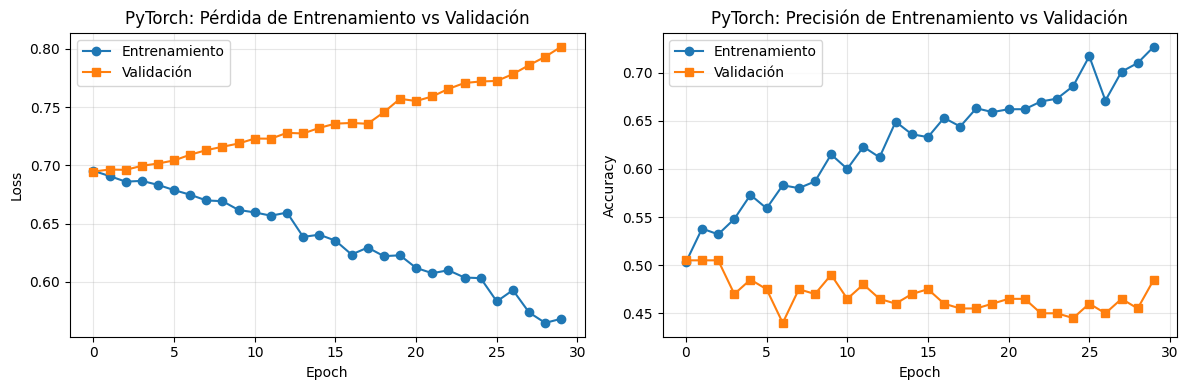

In [26]:
# Graficar curvas de entrenamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.plot(historial_pytorch['loss'], label='Entrenamiento', marker='o')
ax1.plot(historial_pytorch['val_loss'], label='Validación', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('PyTorch: Pérdida de Entrenamiento vs Validación')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(historial_pytorch['accuracy'], label='Entrenamiento', marker='o')
ax2.plot(historial_pytorch['val_accuracy'], label='Validación', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('PyTorch: Precisión de Entrenamiento vs Validación')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Parte 4: Comparación TensorFlow vs PyTorch

In [27]:
# Comparar resultados
print("=" * 50)
print("COMPARACIÓN DE RESULTADOS")
print("=" * 50)
print(f"\nTensorFlow/Keras:")
print(f"  Test Accuracy: {accuracy:.2%}")
print(f"\nPyTorch:")
print(f"  Test Accuracy: {test_accuracy:.2%}")
print(f"\nDiferencia: {abs(accuracy - test_accuracy):.2%}")

COMPARACIÓN DE RESULTADOS

TensorFlow/Keras:
  Test Accuracy: 46.00%

PyTorch:
  Test Accuracy: 43.50%

Diferencia: 2.50%


## Ejercicios Prácticos

### Ejercicio 1: Experimentar con Arquitecturas (TensorFlow)

Crea un modelo con:
- Input: 20 features
- Capas ocultas: 128, 64, 32, 16
- Salida: 1 (binaria)
- Dropout: 0.3 en cada capa oculta

Entrena el modelo y compara su performance con el original.

In [28]:
# Tu código aquí
modelo_grande = keras.Sequential([
    # Agrega las capas aquí
])

modelo_grande.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrena y evalúa

### Ejercicio 2: Comparar Optimizadores

Usando PyTorch, crea 3 versiones del mismo modelo con diferentes optimizadores:
1. SGD (learning_rate=0.01)
2. Adam (learning_rate=0.001)
3. RMSprop (learning_rate=0.001)

¿Cuál converge más rápido?

In [29]:
# Tu código aquí
# Crea 3 modelos y compara
optimizadores = {
    'SGD': optim.SGD(modelo_pytorch.parameters(), lr=0.01),
    'Adam': optim.Adam(modelo_pytorch.parameters(), lr=0.001),
    'RMSprop': optim.RMSprop(modelo_pytorch.parameters(), lr=0.001),
}

### Ejercicio 3: Implementar con Datos Reales

Usando el dataset de:

- https://www.kaggle.com/datasets/nalisha/gaming-vs-academic-performance
- https://www.kaggle.com/datasets/shreyasur965/social-network-ads

1. Normaliza los datos
2. Crea un modelo apropiado en TensorFlow
3. Entrena y evalúa
4. Implementa el mismo modelo en PyTorch y compara


In [30]:
# Tu código aquí
# Carga datos reales, normaliza, y entrena modelos
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Implementa aquí